In [1]:
import matplotlib
import pandas as pd
from sqlalchemy import create_engine
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import os

In [2]:
from forecasting.utils.database import read_sql

df = read_sql("""
SELECT *
FROM mart.mart_fresh_food_order_sale
WHERE date >= '2025-11-01'""")
df.head(1)

,flight_key,flight_number,origin,destination,date,month_name,year,weekday_name,is_weekend,hour_of_departure,day_period,is_night,am_pm,number_of_passengers,item_id,category,price,sold_quantity,potential_error
0,512084ec61e67ed47ecab1dd9466345d,AB144,city_004,city_001,2026-01-12,January,2026.0,Monday,False,0.0,Night,True,AM,174.0,T3L4S016,Salads,15.0,0.0,NaN


In [3]:
df.to_parquet("../interim_files/raw_data_df.parquet")

Dataset limitations:
- Analysis period covers only 4 months.
- Seasonality cannot be reliably evaluated.
- Results should be treated as preliminary.

## 1. Dataset Cleanup

In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check uniqueness of grain (flight_key + item_id)
grain_duplicates = df.duplicated(subset=['flight_key', 'item_id']).sum()
print(f"Duplicate flight_key + item_id combinations: {grain_duplicates}")

Number of duplicate rows: 0
Duplicate flight_key + item_id combinations: 0


In [5]:
# Filtering out errors
print(f"Total records: {len(df)}")
print(f"Records with flags: {df['potential_error'].notna().sum()}")
print(f"Clean records (no flags): {df['potential_error'].isna().sum()}")


error_types = df['potential_error'].value_counts(dropna=True)
print(f"Potential error type: {error_types}")
df = df[df["potential_error"].isna()]


Total records: 59630
Records with flags: 20
Clean records (no flags): 59610
Potential error type: potential_error
no_pax_data       10
zero_pax_count    10
Name: count, dtype: int64


In [6]:
# (1.1.) dataset summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "unique": df.nunique()
})
print(summary)

                               dtype  nulls  unique
flight_key                       str      0    6193
flight_number                    str      0      86
origin                           str      0      29
destination                      str      0      30
date                  datetime64[us]      0     120
month_name                       str      0       4
year                         float64      0       2
weekday_name                     str      0       7
is_weekend                      bool      0       2
hour_of_departure            float64      0      24
day_period                       str      0       4
is_night                        bool      0       2
am_pm                            str      0       2
number_of_passengers         float64      0     187
item_id                          str      0      10
category                         str      0       6
price                        float64      0       7
sold_quantity                float64      0      33
potential_er

## 2. Target Analysis

### 2.1. Target Descriptive Statistics

In [7]:
import numpy as np

# Basic description
target = 'sold_quantity'
print("Numerical Features Summary:")
print(df[target].describe())

print("\n" + "="*80)
print("Distribution metrics:")
print(f"  Skewness: {df[target].skew():.2f}")
print(f"  Kurtosis: {df[target].kurtosis():.2f}")
print(f"  Zeros: {(df[target] == 0).sum()} ({(df[target] == 0).sum() / len(df) * 100:.1f}%)")
print(f"  Non-zero sales: {(df[target] > 0).sum()} ({(df[target] > 0).sum()/len(df)*100:.1f}%)")

# Distribution by percentile
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentile distribution:")
for p in percentiles:
    print(f"  {p*100:.0f}%: {df[target].quantile(p):.1f}")

Numerical Features Summary:
count    59610.000000
mean         0.644238
std          1.367906
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         42.000000
Name: sold_quantity, dtype: float64

Distribution metrics:
  Skewness: 6.99
  Kurtosis: 104.56
  Zeros: 37830 (63.5%)
  Non-zero sales: 21780 (36.5%)

Percentile distribution:
  10%: 0.0
  25%: 0.0
  50%: 0.0
  75%: 1.0
  90%: 2.0
  95%: 3.0
  99%: 6.0


### 2.2. Target Outlier Analysis

Sold Quantity Outliers: 3488 (5.9%)
Bounds: [-1.5, 2.5]
Max value: 42.0


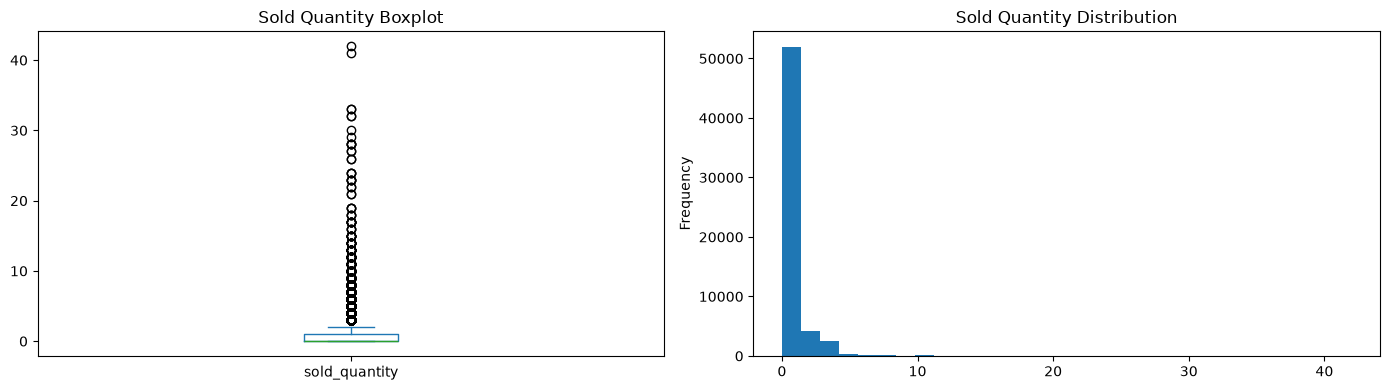

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# IQR method for outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze sold_quantity outliers
outliers, lower, upper = detect_outliers_iqr(df, 'sold_quantity')
print(f"Sold Quantity Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Max value: {df['sold_quantity'].max()}")

# Visualize
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')
df['sold_quantity'].plot(kind='box', ax=axes[0], title='Sold Quantity Boxplot')
df['sold_quantity'].plot(kind='hist', bins=30, ax=axes[1], title='Sold Quantity Distribution')
plt.tight_layout()
plt.show()

In [9]:
# Target variable analysis
print("Target Variable: sold_quantity")
print(f"Mean: {df['sold_quantity'].mean():.2f}")
print(f"Median: {df['sold_quantity'].median():.2f}")
print(f"Std: {df['sold_quantity'].std():.2f}")
print(f"Zero sales: {(df['sold_quantity'] == 0).sum()} ({(df['sold_quantity'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Non-zero sales: {(df['sold_quantity'] > 0).sum()} ({(df['sold_quantity'] > 0).sum()/len(df)*100:.1f}%)")

# Distribution by percentile
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\nPercentile distribution:")
for p in percentiles:
    print(f"  {p*100:.0f}%: {df['sold_quantity'].quantile(p):.1f}")

Target Variable: sold_quantity
Mean: 0.64
Median: 0.00
Std: 1.37
Zero sales: 37830 (63.5%)
Non-zero sales: 21780 (36.5%)

Percentile distribution:
  10%: 0.0
  25%: 0.0
  50%: 0.0
  75%: 1.0
  90%: 2.0
  95%: 3.0
  99%: 6.0


## 5. Numerical Feature Analysis

### 5.1. Numerical Features Descriptive Statistics

In [10]:
import numpy as np

# Numerical features
numerical_cols = ['price', 'hour_of_departure', 'number_of_passengers']
print("Numerical Features Summary:")
print(df[numerical_cols].describe())

print("\n" + "="*80)
print("Distribution metrics:")
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")
    print(f"  Zeros: {(df[col] == 0).sum()} ({(df[col] == 0).sum() / len(df) * 100:.1f}%)")

Numerical Features Summary:
              price  hour_of_departure  number_of_passengers
count  59610.000000       59610.000000          59610.000000
mean      16.847022          13.054186            154.557743
std        8.175116           6.442286             31.108003
min        7.000000           0.000000             13.000000
25%        7.000000           9.000000            145.000000
50%       15.000000          14.000000            168.000000
75%       25.000000          19.000000            174.000000
max       30.000000          23.000000            355.000000

Distribution metrics:

price:
  Skewness: 0.20
  Kurtosis: -1.27
  Zeros: 0 (0.0%)

hour_of_departure:
  Skewness: -0.11
  Kurtosis: -0.99
  Zeros: 1240 (2.1%)

number_of_passengers:
  Skewness: -1.08
  Kurtosis: 4.66
  Zeros: 0 (0.0%)


### 5.2. Numerical Features Correlation Analysis

In [11]:
# checking passenger count cases equal to 0
zero_cases = df[df["number_of_passengers"] == 0]
print(zero_cases)

Empty DataFrame
Columns: [flight_key, flight_number, origin, destination, date, month_name, year, weekday_name, is_weekend, hour_of_departure, day_period, is_night, am_pm, number_of_passengers, item_id, category, price, sold_quantity, potential_error]
Index: []


Correlation with sold_quantity:
price                   0.118088
hour_of_departure       0.067027
number_of_passengers    0.026458
year                   -0.018467
Name: sold_quantity, dtype: float64


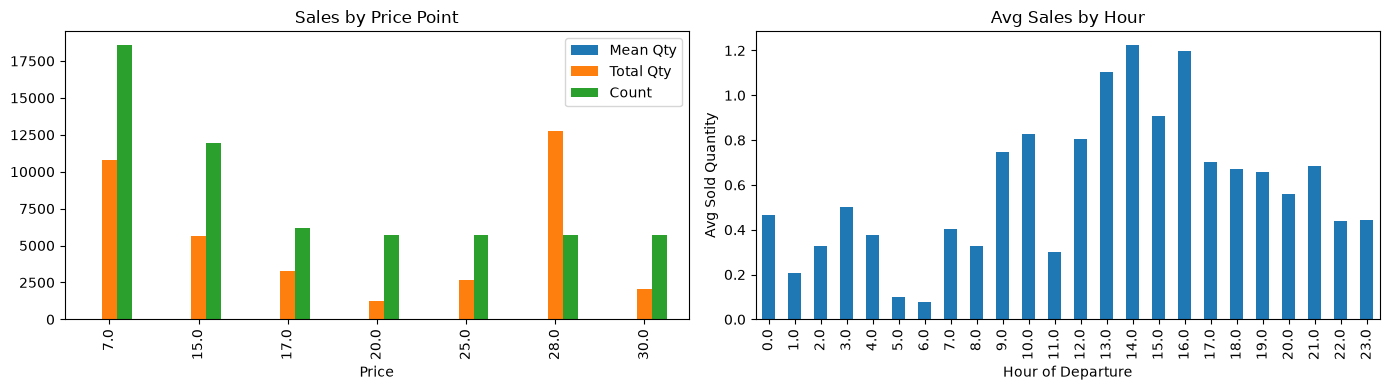

In [12]:
# Correlation with target
numerical_features = ['price', 'hour_of_departure', 'year', 'number_of_passengers']
correlations = df[numerical_features + ['sold_quantity']].corr()['sold_quantity'].drop('sold_quantity').sort_values(ascending=False)

print("Correlation with sold_quantity:")
print(correlations)

# Price vs sold quantity
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Price distribution
df.groupby('price')['sold_quantity'].agg(['mean', 'sum', 'count']).plot(kind='bar', ax=axes[0], title='Sales by Price Point')
axes[0].set_xlabel('Price')
axes[0].legend(['Mean Qty', 'Total Qty', 'Count'])

# Hour distribution
df.groupby('hour_of_departure')['sold_quantity'].mean().plot(kind='bar', ax=axes[1], title='Avg Sales by Hour')
axes[1].set_xlabel('Hour of Departure')
axes[1].set_ylabel('Avg Sold Quantity')

plt.tight_layout()
plt.show()

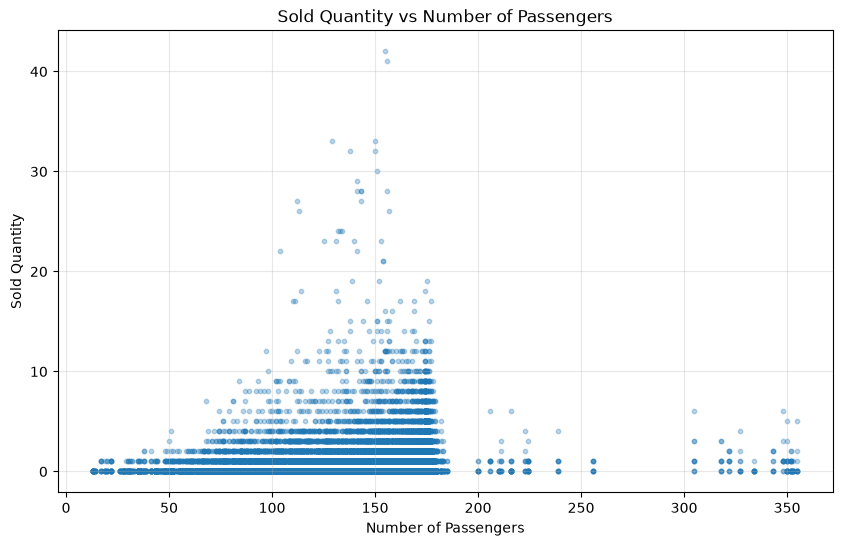

In [13]:
# Scatter plot: sold_quantity vs number_of_passengers
fig, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='white')

# Create scatter plot
ax.scatter(df['number_of_passengers'], df['sold_quantity'], alpha=0.3, s=10)
ax.set_xlabel('Number of Passengers')
ax.set_ylabel('Sold Quantity')
ax.set_title('Sold Quantity vs Number of Passengers')
ax.grid(True, alpha=0.3)
plt.show()

## 6. Categorical Feature Analysis

In [14]:
categorical_features = ['item_id', 'origin', 'destination', 'day_period', 'weekday_name', 'is_weekend', 'is_night']

print("Categorical Features Cardinality:")
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")

# Analyze key categorical features
print("\n" + "="*80)
print("Sales by Item:")
item_sales = df.groupby('item_id').agg({
    'sold_quantity': ['mean', 'sum', 'count'],
    'price': 'mean'
}).round(2)
item_sales.columns = ['avg_qty', 'total_qty', 'observations', 'avg_price']
print(item_sales.sort_values('total_qty', ascending=False))

print("\n" + "="*80)
print("Sales by Day Period:")
print(df.groupby('day_period')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Weekend:")
print(df.groupby('is_weekend')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

Categorical Features Cardinality:
item_id: 10 unique values
origin: 29 unique values
destination: 30 unique values
day_period: 4 unique values
weekday_name: 7 unique values
is_weekend: 2 unique values
is_night: 2 unique values

Sales by Item:
          avg_qty  total_qty  observations  avg_price
item_id                                              
T3L4D007     2.23    12760.0          5729       28.0
C3L2D037     0.64     3986.0          6193        7.0
C3L2D041     0.63     3904.0          6193        7.0
T3L4D129     0.58     3333.0          5729       15.0
C3L2W121     0.53     3291.0          6193       17.0
C3L2D043     0.46     2878.0          6193        7.0
T3L4D008     0.47     2665.0          5729       25.0
T3L4S016     0.37     2306.0          6193       15.0
T3L4D127     0.35     2028.0          5729       30.0
C3L2W161     0.22     1252.0          5729       20.0

Sales by Day Period:
            mean      sum  count
day_period                      
Day         1.02  168

## 7. Route Analysis (Origin-Destination)

In [15]:
# Top routes by volume
df['route'] = df['origin'] + ' -> ' + df['destination']
route_analysis = df.groupby('route').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
}).round(2)
route_analysis.columns = ['total_qty', 'num_flights']
route_analysis['avg_qty_per_flight'] = (route_analysis['total_qty'] / route_analysis['num_flights']).round(2)
route_analysis = route_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
route_analysis = route_analysis.sort_values('total_qty', ascending=False)

print("Top 10 Routes by Total Sales:")
print(route_analysis.head(10))

print("\n" + "="*80)
print("Top Origins:")
origin_analysis = df.groupby('origin').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
origin_analysis.columns = ['total_qty', 'num_flights']
origin_analysis['avg_qty_per_flight'] = (origin_analysis['total_qty'] / origin_analysis['num_flights']).round(2)
origin_analysis = origin_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(origin_analysis.sort_values('total_qty', ascending=False).head(10))

print("\n" + "="*80)
print("Top Destinations:")
dest_analysis = df.groupby('destination').agg({
    'sold_quantity': 'sum',
    'flight_key': 'nunique'
})
dest_analysis.columns = ['total_qty', 'num_flights']
dest_analysis['avg_qty_per_flight'] = (dest_analysis['total_qty'] / dest_analysis['num_flights']).round(2)
dest_analysis = dest_analysis[['avg_qty_per_flight', 'total_qty', 'num_flights']]
print(dest_analysis.sort_values('total_qty', ascending=False).head(10))

Top 10 Routes by Total Sales:
                      avg_qty_per_flight  total_qty  num_flights
route                                                           
city_001 -> city_002                6.12     1984.0          324
city_001 -> city_008                6.80     1878.0          276
city_017 -> city_001               15.12     1845.0          122
city_003 -> city_001               13.22     1600.0          121
city_001 -> city_017               13.30     1596.0          120
city_001 -> city_003               11.78     1425.0          121
city_001 -> city_011                4.75     1419.0          299
city_001 -> city_005               11.25     1328.0          118
city_001 -> city_018               15.33     1318.0           86
city_020 -> city_001               10.72     1233.0          115

Top Origins:
          avg_qty_per_flight  total_qty  num_flights
origin                                              
city_001                7.30    22641.0         3101
city_017         

## 8. Binning Analysis

In [16]:
# Pax binning
df['pax_bin'] = pd.cut(df['number_of_passengers'],
                        bins=[0, 100, 150, 180, 355],
                        labels=['> 100', "100 - 150", "150 - 180", '180 <'],
                        include_lowest=True)

print("Sales by Pax Bin:")
df_pax = df.groupby('pax_bin')[['sold_quantity', "flight_key", "number_of_passengers"]].agg(
    total_sales = ("sold_quantity", "sum"),
    flights_count = ("flight_key", "count"),
    total_pax = ("number_of_passengers", "sum")).round(2)
df_pax["avg_sale_per_flight"] = df_pax["total_sales"] / df_pax["flights_count"]
df_pax["avg_sale_per_pax"] = df_pax["total_sales"] / df_pax["total_pax"]
print(df_pax)

# Price binning
df['price_bin'] = pd.cut(df['price'], bins=[0, 7, 17, 30], labels=['Low', 'Medium', 'High'], duplicates='drop')

print("\n" + "="*80)
print("Sales by Price Bin:")
print(df.groupby('price_bin')[['sold_quantity']].agg(['mean', 'sum', 'count']).round(2))

Sales by Pax Bin:
           total_sales  flights_count   total_pax  avg_sale_per_flight  \
pax_bin                                                                  
> 100           1931.0           4775   367780.00             0.404398   
100 - 150       9118.0          12600  1638949.25             0.723651   
150 - 180      27153.0          41930  7126239.05             0.647579   
180 <            201.0            305    80218.73             0.659016   

           avg_sale_per_pax  
pax_bin                      
> 100              0.005250  
100 - 150          0.005563  
150 - 180          0.003810  
180 <              0.002506  

Sales by Price Bin:
          sold_quantity                
                   mean      sum  count
price_bin                              
Low                0.58  10768.0  18579
Medium             0.49   8930.0  18115
High               0.82  18705.0  22916


## 9. Time-Based Analysis

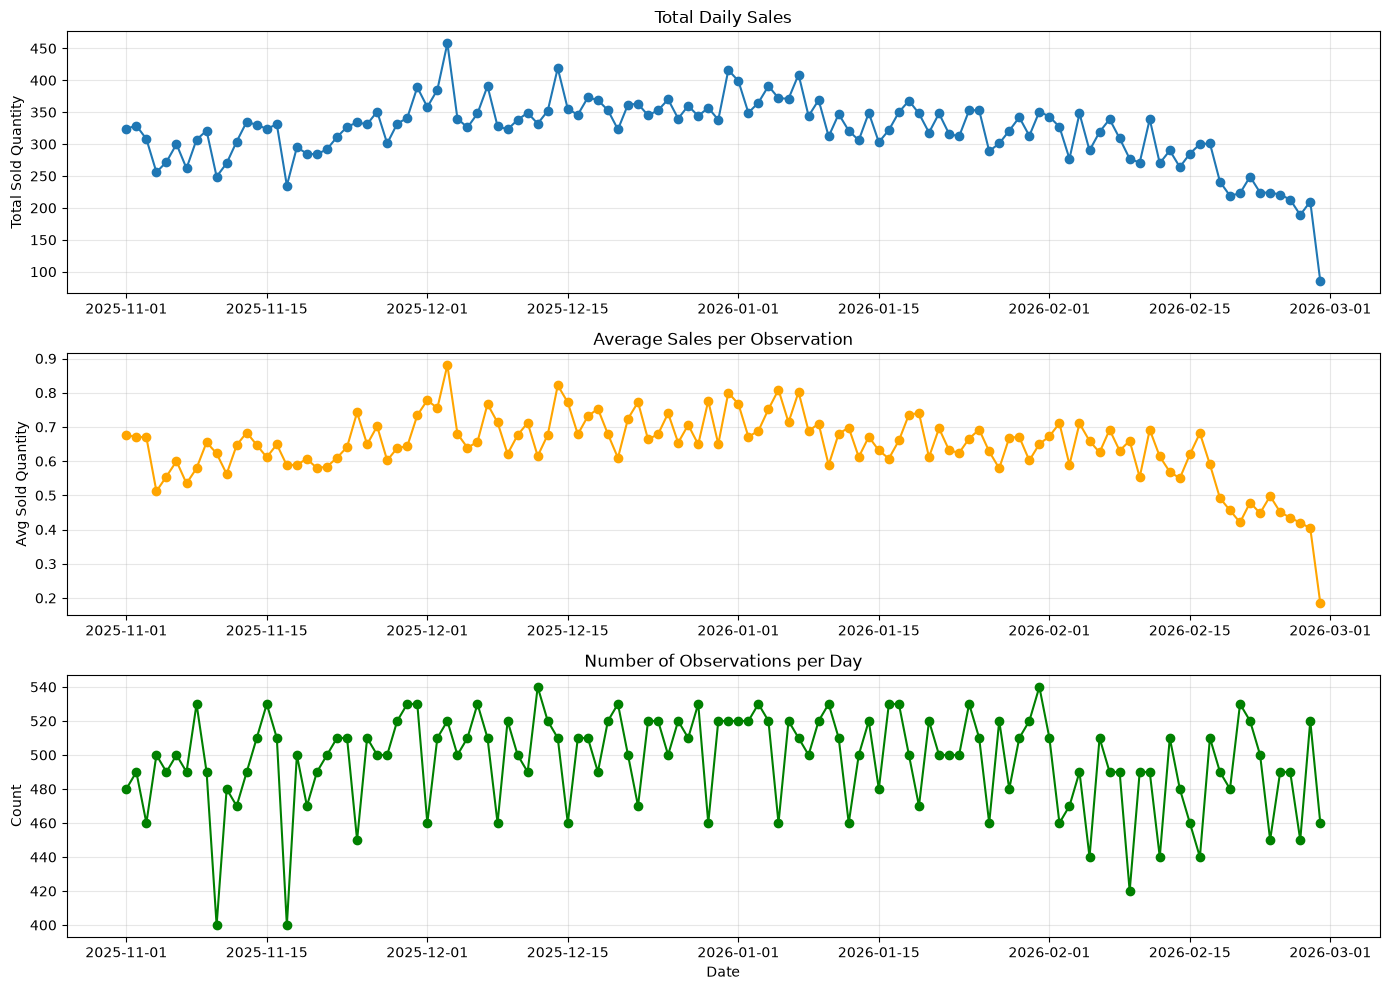

Sales by Weekday:
              mean     sum  count
weekday_name                     
Friday        0.60  5274.0   8770
Monday        0.70  5345.0   7640
Saturday      0.61  5658.0   9280
Sunday        0.68  5833.0   8580
Thursday      0.64  5320.0   8280
Tuesday       0.61  5255.0   8590
Wednesday     0.68  5718.0   8470

Sales by Month:
            mean      sum  count
month_name                      
December    0.71  11114.0  15670
February    0.55   7447.0  13480
January     0.68  10612.0  15720
November    0.63   9230.0  14740


In [17]:
# Daily trends
daily_sales = df.groupby('date')['sold_quantity'].agg(['mean', 'sum', 'count']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Total sales over time
axes[0].plot(daily_sales['date'], daily_sales['sum'], marker='o')
axes[0].set_title('Total Daily Sales')
axes[0].set_ylabel('Total Sold Quantity')
axes[0].grid(True, alpha=0.3)

# Average sales over time
axes[1].plot(daily_sales['date'], daily_sales['mean'], marker='o', color='orange')
axes[1].set_title('Average Sales per Observation')
axes[1].set_ylabel('Avg Sold Quantity')
axes[1].grid(True, alpha=0.3)

# Number of observations
axes[2].plot(daily_sales['date'], daily_sales['count'], marker='o', color='green')
axes[2].set_title('Number of Observations per Day')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sales by Weekday:")
print(df.groupby('weekday_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

print("\n" + "="*80)
print("Sales by Month:")
print(df.groupby('month_name')['sold_quantity'].agg(['mean', 'sum', 'count']).round(2))

## 10. Initial Feature Selection Conclusions

The exploratory analysis identifies `item_id`, `route`, `day_period`, and `pax_bin` as the most informative features for demand forecasting, 
while `is_weekend`, `weekday_name`, and raw temporal features show no meaningful predictive signal and are candidates for exclusion.

### High-importance features

- **`item_id`** - Strong product-level heterogeneity. Top performer T3L4D007 (avg 4.45 units) vs lowest C3L2W161 (avg 0.44) shows 10x difference. After excluding T3L4D007 outlier, low-price items outperform (avg 1.16) vs high-price (avg 0.69), confirming price elasticity is product-dependent.

- **`route`** - Substantial route-level variation with symmetric patterns across outbound/return pairs (consistent with hub-based catering). Premium routes (city_017 ↔ city_001: ~29 items/flight) vs economy routes (city_002 ↔ city_001: ~10 items/flight) show 3x demand variation.

- **`day_period`** - Clear time-of-day effects: Day flights (1.72 avg) outperform Night flights (0.89 avg) by 93%. Morning shows high observation count but lower conversion (1.04 avg).

- **`pax_bin`** (derived from number_of_passengers) - Non-linear threshold effect: 100–150 passenger range shows optimal per-flight sales (1.45 avg). Per-passenger sales decline monotonically with capacity (0.0133 → 0.0044), but total volume peaks at 150–180 due to flight frequency.

- **`price` or `price_bin`** (in conjunction with item_id) - Cannot be interpreted independently. Excluding T3L4D007, price shows standard negative elasticity. Must be modeled with item interactions. For now, this feature is skipped because of item_id being taken to the model. And items with prices have almost one-to-one relation.

### Medium-importance features

- **`hour_of_departure`** - Shows variation but highly correlated with day_period (redundant). May be useful for fine-grained time patterns if day_period is insufficient.

- **`origin/destination`** (individual) - city_001 hub dominates (38k total sales), but route-level (OD pairs) more predictive than individual cities.

### Low-importance features

- **`weekday_name` / `is_weekend`** - Virtually no difference (1.29 vs 1.28 avg). Weekend effect negligible across the dataset.

- **`month_name`** - Only 4 months available, insufficient for seasonality. No consistent monthly patterns detected.

- **`year`** - Only 2 values (2025, 2026), no temporal signal.

- **`is_night`** - Fully redundant with day_period.


### Recommended modeling approaches

Based on the characteristics identified above, the following approaches will be evaluated:

1. **Baseline**: Historical mean aggregated at flight-product level
2. **Tree-based models**: Random Forest, LightGBM, XGBoost (handle non-linearity, interactions, zero-inflation)
3. **Statistical models**: Poisson regression, Negative Binomial (appropriate for count data)
4. **Two-stage pipeline**: 
   - Stage 1: Binary classifier (zero vs non-zero sales)
   - Stage 2: Regression on non-zero samples (handles zero-inflation explicitly)
5. **Neighborhood-based**: KNN (captures local patterns in feature space)

**Alternative granularity**: If flight-level performance is insufficient, re-aggregate dataset at route level (combining outbound/return as single catering line) to reflect operational planning unit.

**Validation strategy**: 
- Time-based split (last month for validation to respect temporal ordering)
- Stratify by item_id to ensure all products in train/test
- Avoid MSE/RMSE metrics (penalize outliers excessively) — use MAE, MAPE, or Poisson deviance

In [18]:
# temporary storing df to csv
df.to_csv("../interim_files/notebooks/df.csv")